c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>> [1/5] Loading and Engineering Data...
>> Data Loaded. Shape: (113, 620)

>> [3/5] Running Comparative Analysis (Stratified 5-Fold CV)...

Model                  | Total Acc | AUC      | CUT Acc  | HOLD Acc | RAISE Acc
Baseline (Method 1)    | 74.34%    | 0.8460   | 37.50%   | 86.75%   | 40.91%
Enhanced Model         | 81.42%    | 0.8884   | 62.50%   | 91.57%   | 50.00%
Agent (Logistic)       | 83.19%    | 0.9002   | 62.50%   | 90.36%   | 63.64%
Agent (RF)             | 78.76%    | 0.9145   | 25.00%   | 95.18%   | 36.36%
Agent (XGB)            | 83.19%    | 0.9009   | 62.50%   | 93.98%   | 50.00%
Agent (Ensemble)       | 84.07%    | 0.9035   | 62.50%   | 93.98%   | 54.55%
------------------------------------------------------------------------------------------

>> [5/6] Generating SHAP Plot for Baseline (Method 1)...


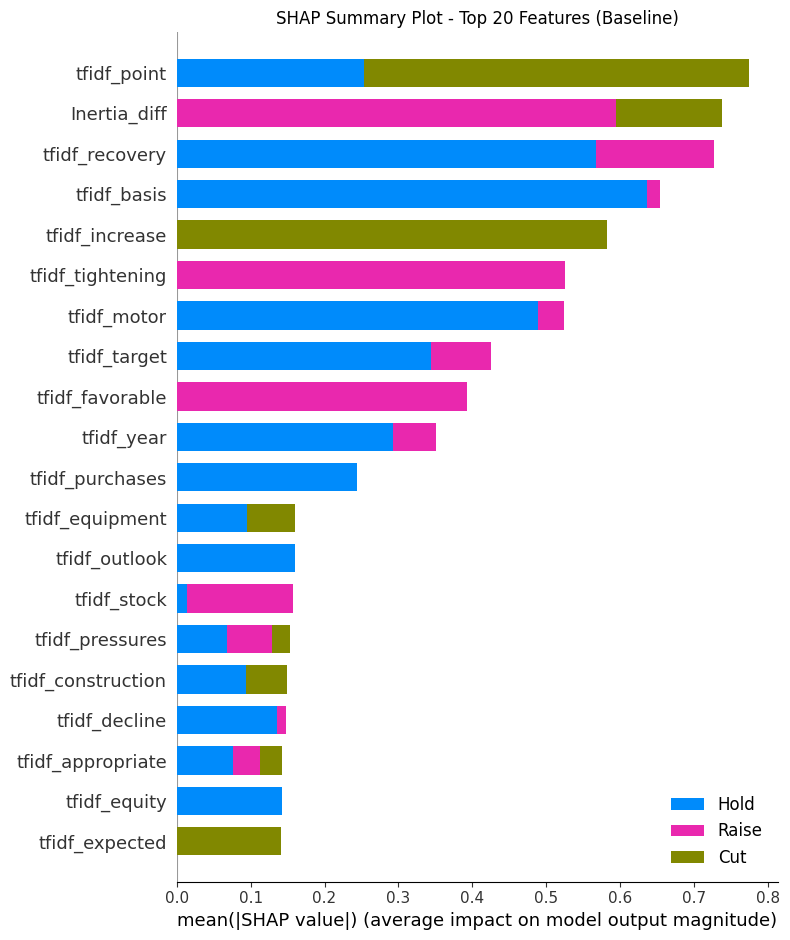


>> [6/6] Generating SHAP Plot for Enhanced Model...


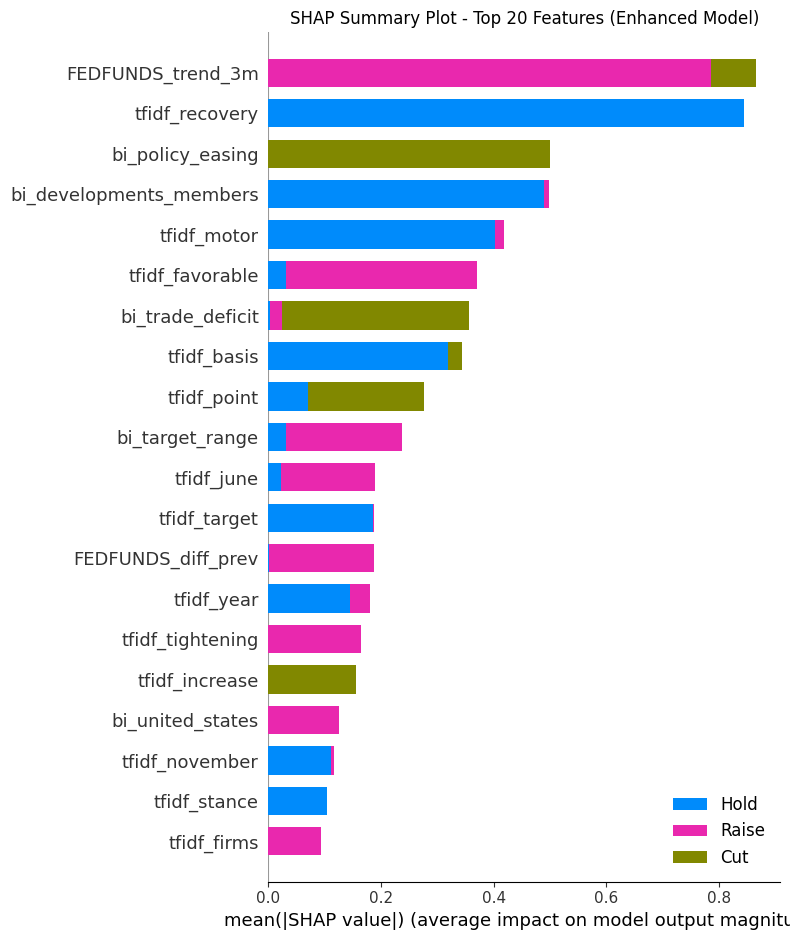

In [1]:
import pandas as pd
import numpy as np
import os
import re
import string
import matplotlib.pyplot as plt
import shap
import warnings

# Machine Learning Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# =============================================================================
# 1. CONFIGURATION
# =============================================================================
CONFIG = {
    "PATH_ECON": "structured_data", 
    "FILE_MINUTES": "FOMC_Minutes_1999_2025.csv",
    "FILE_DICT": "Loughran-McDonald_MasterDictionary_1993-2024.csv",
    "DATE_START": "2011-01-01",      
    "DATE_END": "2025-01-01",
    "RANDOM_SEED": 42
}

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# =============================================================================
# 2. DATA PROCESSING
# =============================================================================
def load_and_engineer_features():
    print(">> [1/5] Loading and Engineering Data...")
    
    # --- A. Economic Data ---
    files = {
        'HOUST': ('HOUST.csv', 'HOUST', 12), 'HPI': ('HPI.csv', 'CSUSHPISA', 12),
        'CPI': ('CPIAUCSL.csv', 'CPIAUCSL', 12), 'PCE': ('PCE.csv', 'PCE', 12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS', 1), 'UNRATE': ('UNRATE.csv', 'UNRATE', 1),
        'NFP': ('NFP.csv', 'PAYEMS', 1), 'SPREAD': ('T10Y3MM.csv', 'T10Y3MM', 1)
    }
    
    series_list = []
    for key, (fname, col, lag) in files.items():
        fp = os.path.join(CONFIG['PATH_ECON'], fname)
        if os.path.exists(fp):
            df = pd.read_csv(fp, parse_dates=['observation_date']).set_index('observation_date').sort_index()
            df = df[~df.index.duplicated(keep='first')] 
            
            s = df[col] if col in df.columns else df.iloc[:, 0]
            
            if key in ['CPI', 'PCE']:
                feat = s.pct_change(lag) * 100
                feat.name = f'{key}_Inflation_Rate'
            else:
                feat = s.diff(lag)
                suffix = 'year' if lag == 12 else 'prev'
                feat.name = f'{key}_diff_{suffix}'
            
            roll = s.rolling(3).mean()
            trend = roll.diff(lag)
            trend.name = f'{key}_trend_3m'
            
            series_list.extend([feat, trend])

    df_econ = pd.concat(series_list, axis=1).dropna()
    df_econ.index = df_econ.index.to_period('M').to_timestamp()
    df_econ = df_econ.groupby(level=0).last() 

    # --- B. Text Data ---
    df_txt = pd.read_csv(CONFIG['FILE_MINUTES'])
    
    df_txt['date'] = df_txt['Link'].apply(lambda x: re.search(r'(\d{8})', str(x)).group(1) if re.search(r'(\d{8})', str(x)) else None)
    df_txt['observation_date'] = pd.to_datetime(df_txt['date'], format='%Y%m%d', errors='coerce')
    df_txt = df_txt.dropna(subset=['observation_date']).set_index('observation_date').sort_index()
    
    df_txt.index = df_txt.index.to_period('M').to_timestamp()
    df_txt = df_txt.groupby(level=0).agg({'Text': ' '.join}).dropna()
    
    df_txt['clean'] = df_txt['Text'].apply(clean_text)

    # TF-IDF
    tfidf_uni = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 1))
    uni_mat = tfidf_uni.fit_transform(df_txt['clean'])
    df_uni = pd.DataFrame(uni_mat.toarray(), columns=[f"tfidf_{w}" for w in tfidf_uni.get_feature_names_out()], index=df_txt.index)

    tfidf_bi = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(2, 2))
    bi_mat = tfidf_bi.fit_transform(df_txt['clean'])
    df_bi = pd.DataFrame(bi_mat.toarray(), columns=[f"bi_{w.replace(' ','_')}" for w in tfidf_bi.get_feature_names_out()], index=df_txt.index)

    # Sentiment
    if os.path.exists(CONFIG['FILE_DICT']):
        lm_dict = pd.read_csv(CONFIG['FILE_DICT'])
        lm_neg = set(lm_dict[lm_dict['Negative'] > 0]['Word'].str.lower())
    else:
        lm_neg = {'recession', 'weak', 'decline', 'risk', 'downside', 'unemployment'}

    def get_sentiment(text):
        tokens = text.split()
        if not tokens: return 0.0
        neg_count = sum(1 for t in tokens if t in lm_neg)
        return neg_count / len(tokens)

    df_sent = df_txt['clean'].apply(get_sentiment)
    df_sent.name = 'LM_Negative'

    # --- C. Merge ---
    df_merged = pd.concat([df_econ, df_uni, df_bi, df_sent], axis=1, join='inner')
    
    target_series = df_merged['FEDFUNDS_diff_prev'].shift(-1)
    df_merged['Next_Change'] = target_series
    df_merged = df_merged.dropna(subset=['Next_Change'])
    
    df_final = df_merged.loc[CONFIG['DATE_START']:CONFIG['DATE_END']].copy()
    
    conditions = [
        (df_final['Next_Change'] < -0.05),
        (df_final['Next_Change'] > 0.05)
    ]
    df_final['Target'] = np.select(conditions, [-1, 1], default=0)
    
    label_map = {-1: 0, 0: 1, 1: 2} # 0: Cut, 1: Hold, 2: Raise
    df_final['Target_Map'] = df_final['Target'].map(label_map)
    
    return df_final

# =============================================================================
# 3. AGENT MODEL DEFINITION
# =============================================================================
class AgentModel(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.agent_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
        self.agent_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
        self.agent_xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='mlogloss')
        self.meta_learner = LogisticRegression()
        
    def fit(self, X, y):
        self.agent_lr.fit(X, y)
        self.agent_rf.fit(X, y)
        self.agent_xgb.fit(X, y)
        
        meta_features = np.hstack([
            self.agent_lr.predict_proba(X),
            self.agent_rf.predict_proba(X),
            self.agent_xgb.predict_proba(X)
        ])
        
        self.meta_learner.fit(meta_features, y)
        return self

    def predict(self, X):
        meta = self._get_meta(X)
        return self.meta_learner.predict(meta)
    
    def predict_proba(self, X):
        meta = self._get_meta(X)
        return self.meta_learner.predict_proba(meta)

    def _get_meta(self, X):
        return np.hstack([
            self.agent_lr.predict_proba(X),
            self.agent_rf.predict_proba(X),
            self.agent_xgb.predict_proba(X)
        ])

# =============================================================================
# 4. EXECUTION
# =============================================================================
def run_research_pipeline():
    # 1. Load Data
    try:
        df = load_and_engineer_features()
        print(f">> Data Loaded. Shape: {df.shape}")
    except Exception as e:
        print(f"Error: {e}")
        return

    X = df.drop(columns=['Next_Change', 'Target', 'Target_Map'])
    y = df['Target_Map']

    # 2. Define Features for Baseline vs Enhanced
    # Baseline: Economic + Unigrams + Sentiment
    cols_base = [c for c in X.columns if 'tfidf_' in c or 'Inflation_Rate' in c or 'diff_' in c or 'LM_' in c]
    # Enhanced: All Features (includes Bigrams, Trends, etc.)
    cols_enh = X.columns.tolist()

    # 3. Define Models
    models = {
        'Baseline (Method 1)': (XGBClassifier(n_estimators=100, max_depth=4, random_state=42), cols_base),
        'Enhanced Model':      (XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42), cols_enh),
        'Agent (Logistic)':    (LogisticRegression(max_iter=2000, class_weight='balanced'), cols_enh),
        'Agent (RF)':          (RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42), cols_enh),
        'Agent (XGB)':         (XGBClassifier(n_estimators=100, max_depth=3, random_state=42), cols_enh),
        'Agent (Ensemble)':    (AgentModel(), cols_enh)
    }

    # 4. Comparative Analysis
    print("\n>> [3/5] Running Comparative Analysis (Stratified 5-Fold CV)...")
    predictions_log = {k: {'true': [], 'pred': [], 'probs': []} for k in models}
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['RANDOM_SEED'])
    scaler = StandardScaler()

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        try:
            sm = SMOTE(k_neighbors=1, random_state=42)
            X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
        except:
            X_train_res, y_train_res = X_train, y_train

        for name, (model, cols) in models.items():
            X_tr_curr = X_train_res[cols]
            X_te_curr = X_test[cols]
            
            X_tr_sc = scaler.fit_transform(X_tr_curr)
            X_te_sc = scaler.transform(X_te_curr)
            
            model.fit(X_tr_sc, y_train_res)
            
            preds = model.predict(X_te_sc)
            probs = model.predict_proba(X_te_sc)
            
            # Pad probabilities if classes are missing
            if probs.shape[1] < 3:
                full_probs = np.zeros((probs.shape[0], 3))
                for i, cls_label in enumerate(model.classes_):
                    full_probs[:, cls_label] = probs[:, i]
                probs = full_probs

            predictions_log[name]['true'].extend(y_test)
            predictions_log[name]['pred'].extend(preds)
            predictions_log[name]['probs'].append(probs)

    # 5. Results Table
    print("\n" + "="*90)
    print(f"{'Model':<22} | {'Total Acc':<9} | {'AUC':<8} | {'CUT Acc':<8} | {'HOLD Acc':<8} | {'RAISE Acc':<8}")
    print("="*90)
    
    for name, data in predictions_log.items():
        y_true = np.array(data['true'])
        y_pred = np.array(data['pred'])
        y_probs = np.vstack(data['probs'])
        
        acc = accuracy_score(y_true, y_pred)
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr')
        except ValueError:
            auc = 0.0
        
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        with np.errstate(divide='ignore', invalid='ignore'):
            per_class_acc = cm.diagonal() / cm.sum(axis=1)
            per_class_acc = np.nan_to_num(per_class_acc)
            
        print(f"{name:<22} | {acc:.2%}    | {auc:.4f}   | {per_class_acc[0]:.2%}   | {per_class_acc[1]:.2%}   | {per_class_acc[2]:.2%}")
    print("-" * 90)

    # 6. SHAP Plot (Method 1 - Baseline)
    print("\n>> [5/6] Generating SHAP Plot for Baseline (Method 1)...")
    try:
        X_shap = X[cols_base]
        # Rename for readability
        rename_map = {
            'FEDFUNDS_diff_prev': 'Inertia_diff',
            'SPREAD_diff_prev': '10YUST_diff_prev',
            'HOUST_diff_year': 'HOUST_diff_year',
            'HPI_diff_year': 'HPI_diff_year',
            'NFP_diff_prev': 'NFP_diff_prev'
        }
        X_shap = X_shap.rename(columns=rename_map)
        
        final_model = XGBClassifier(n_estimators=100, max_depth=4, random_state=42)
        final_model.fit(X_shap, y)
        
        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_shap)
        
        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            shap_values, 
            X_shap, 
            plot_type="bar", 
            class_names=["Cut", "Hold", "Raise"],
            max_display=20,
            show=False
        )
        plt.title("SHAP Summary Plot - Top 20 Features (Baseline)")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"SHAP Error: {e}")

    # 7. SHAP Plot (Enhanced Model)
    print("\n>> [6/6] Generating SHAP Plot for Enhanced Model...")
    try:
        X_enh = X[cols_enh]
        
        enh_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
        enh_model.fit(X_enh, y)
        
        explainer_enh = shap.TreeExplainer(enh_model)
        shap_values_enh = explainer_enh.shap_values(X_enh)
        
        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            shap_values_enh, 
            X_enh, 
            plot_type="bar", 
            class_names=["Cut", "Hold", "Raise"],
            max_display=20,
            show=False
        )
        plt.title("SHAP Summary Plot - Top 20 Features (Enhanced Model)")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"SHAP Error: {e}")

if __name__ == "__main__":
    run_research_pipeline()